In [14]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from pathlib import Path
from tqdm import tqdm
import copy
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PROJECT_ROOT = Path().resolve().parents[1]
DATA_DIR = PROJECT_ROOT / "data"


In [15]:
shotdata_df = pd.read_csv(DATA_DIR / "Shot Chart Details Raw" /"raw_shotchart_S1_to_S4_main.csv")
raw_games_df = pd.read_csv(DATA_DIR / "raw_game_logs_S1_to_S4.csv")
career_total_df = pd.read_csv(DATA_DIR / "career_totals_targets.csv")
player_split_df = pd.read_csv(DATA_DIR / "player_train_test_split_with_score.csv")

# Data Cleaning
shotdata_df['SHOT_MADE_NUMERIC'] = (shotdata_df['SHOT_MADE_FLAG'] == 'Made Shot').astype(float)
shotdata_df = shotdata_df.dropna(subset=['LOC_X', 'LOC_Y', 'SHOT_DISTANCE'])

# remove partial team rows
initial_len = len(career_total_df)
career_total_df['IS_TOT'] = career_total_df['TEAM_ABBREVIATION'] == 'TOT'
career_total_df = career_total_df.sort_values(
        by=['PLAYER_ID', 'SEASON_ID', 'IS_TOT'], 
        ascending=[True, True, False]
    )
career_total_df = career_total_df.drop_duplicates(subset=['PLAYER_ID', 'SEASON_ID'], keep='first')
career_total_df = career_total_df.drop(columns=['IS_TOT'])
print(f"Cleaned dataset: Dropped {initial_len - len(career_total_df)} partial team rows.")


Cleaned dataset: Dropped 1903 partial team rows.


--- GAMES PER SEASON DISTRIBUTION ---
count    3401.00
mean       52.61
std        24.21
min         1.00
50%        59.00
75%        74.00
90%        80.00
95%        82.00
99%        82.00
max        84.00
dtype: float64

--- SHOTS PER GAME DISTRIBUTION ---
count    167270.00
mean          8.05
std           5.33
min           1.00
50%           7.00
75%          11.00
90%          16.00
95%          18.00
99%          23.00
max          40.00
dtype: float64


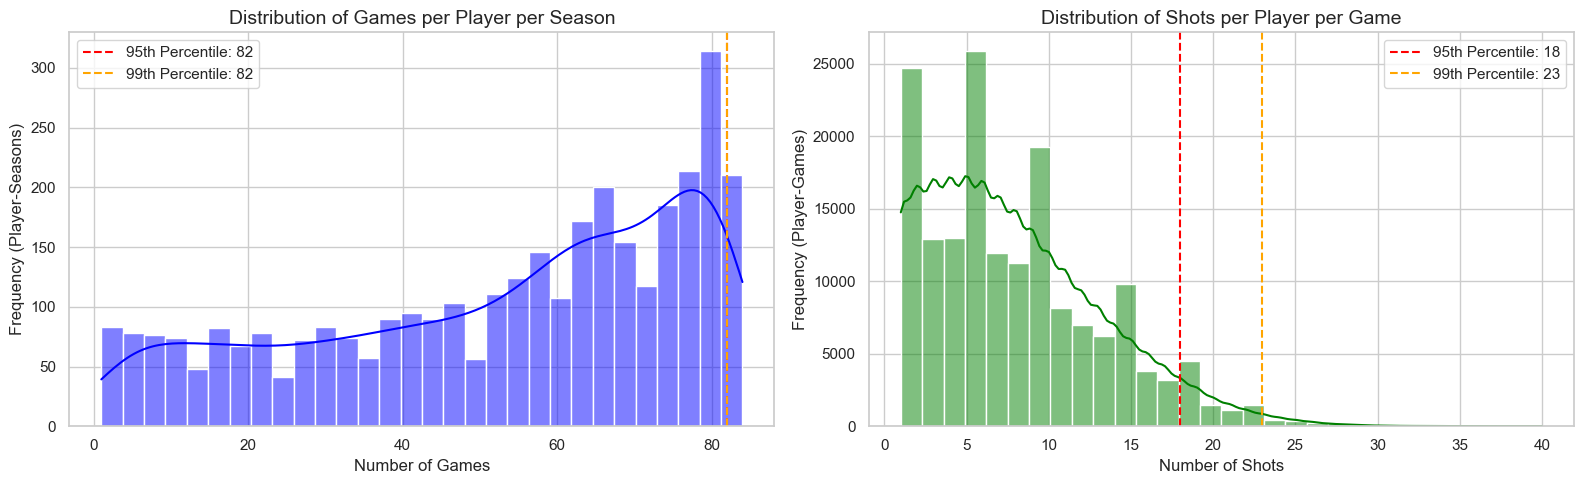

In [16]:
# Visualize Games per Season and Shots Per Game
games_per_season = raw_games_df.groupby(['Player_ID', 'SEASON_ID']).size()
shots_per_game = shotdata_df.groupby(['PLAYER_ID', 'GAME_ID']).size()

print("--- GAMES PER SEASON DISTRIBUTION ---")
print(games_per_season.describe(percentiles=[0.5, 0.75, 0.90, 0.95, 0.99]).round(2))

print("\n--- SHOTS PER GAME DISTRIBUTION ---")
print(shots_per_game.describe(percentiles=[0.5, 0.75, 0.90, 0.95, 0.99]).round(2))

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Games per Season
sns.histplot(games_per_season, bins=30, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of Games per Player per Season', fontsize=14)
axes[0].set_xlabel('Number of Games')
axes[0].set_ylabel('Frequency (Player-Seasons)')

# Add vertical lines for 95th and 99th percentiles
g_95 = games_per_season.quantile(0.95)
g_99 = games_per_season.quantile(0.99)
axes[0].axvline(g_95, color='red', linestyle='--', label=f'95th Percentile: {g_95:.0f}')
axes[0].axvline(g_99, color='orange', linestyle='--', label=f'99th Percentile: {g_99:.0f}')
axes[0].legend()

# Plot 2: Shots per Game
sns.histplot(shots_per_game, bins=30, kde=True, ax=axes[1], color='green')
axes[1].set_title('Distribution of Shots per Player per Game', fontsize=14)
axes[1].set_xlabel('Number of Shots')
axes[1].set_ylabel('Frequency (Player-Games)')

# Add vertical lines for 95th and 99th percentiles
s_95 = shots_per_game.quantile(0.95)
s_99 = shots_per_game.quantile(0.99)
axes[1].axvline(s_95, color='red', linestyle='--', label=f'95th Percentile: {s_95:.0f}')
axes[1].axvline(s_99, color='orange', linestyle='--', label=f'99th Percentile: {s_99:.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()

In [17]:
# ==========================================
# 1. Constants & Features
# ==========================================
MAX_SEASONS = 4
MAX_GAMES = 82
MAX_SHOTS = 23

shot_features = ['LOC_X', 'LOC_Y', 'SHOT_DISTANCE', 'SHOT_MADE_NUMERIC']
game_features = [
    'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 
    'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 
    'STL', 'BLK', 'TOV', 'PF', 'PTS', 'PLUS_MINUS'
]
season_features = ['PLAYER_AGE', 'GP', 'MIN', 'PTS']

TARGET_COLS = [
    'Scoring_Metric_Score',
    'Efficiency_Metric_Score',
    'Playmaking_Metric_Score',
    'Defense_Metric_Score',
    'Control_Metric_Score'
]

# ==========================================
# 2. Season-Level RAM Caching
# ==========================================
def build_season_level_cache(career_df, game_df, shot_df):
    """
    Caches tensors at the (PLAYER_ID, SEASON_ID) level. 
    This prevents OOM errors since sliding windows share seasons.
    """
    season_cache = {}
    
    print("Grouping DataFrames for O(1) lookups (This takes a few seconds)...")
    # career_df needs to be indexed for fast single-row lookups
    career_indexed = career_df.set_index(['PLAYER_ID', 'SEASON_ID'])
    game_grouped = dict(tuple(game_df.groupby(['Player_ID', 'SEASON_ID'])))
    shot_grouped = dict(tuple(shot_df.groupby(['PLAYER_ID', 'GAME_ID'])))

    for (player_id, season_id), season_row in tqdm(career_indexed.iterrows(), total=len(career_indexed)):
        
        season_tensor = np.zeros(len(season_features))
        game_tensor = np.zeros((MAX_GAMES, len(game_features)))
        shot_tensor = np.zeros((MAX_GAMES, MAX_SHOTS, len(shot_features)))
        
        season_tensor[:] = season_row[season_features].values
        
        s_games = game_grouped.get((player_id, season_id))
        if s_games is not None:
            s_games = s_games.head(MAX_GAMES)
            game_tensor[:len(s_games), :] = s_games[game_features].values
            
            for g_idx, g_id in enumerate(s_games['Game_ID']):
                g_shots = shot_grouped.get((player_id, g_id))
                
                if g_shots is not None:
                    g_shots = g_shots.head(MAX_SHOTS)
                    shot_tensor[g_idx, :len(g_shots), :] = g_shots[shot_features].values
                    
        # Store as PyTorch tensors immediately to save conversion time later
        season_cache[(player_id, season_id)] = {
            'season': torch.FloatTensor(season_tensor),
            'games': torch.FloatTensor(game_tensor),
            'shots': torch.FloatTensor(shot_tensor)
        }
        
    return season_cache

# Execute the cache build
data_cache = build_season_level_cache(career_total_df, raw_games_df, shotdata_df)

# ==========================================
# 3. Dynamic PyTorch Dataset
# ==========================================
def parse_input_seasons(input_season_str):
    """
    Converts "2016-2020" into a list of exact season strings: 
    ['2016-17', '2017-18', '2018-19', '2019-20']
    """
    start_yr, end_yr = map(int, input_season_str.split('-'))
    seasons = []
    for y in range(start_yr, end_yr):
        next_yr_suffix = str(y + 1)[-2:] # Gets '17' from 2017
        seasons.append(f"{y}-{next_yr_suffix}")
    return seasons
    

class NBASlidingWindowDataset(Dataset):
    def __init__(self, split_df, cache, target_cols):
        # Convert df to list of dictionaries for much faster row access during training
        self.samples = split_df.to_dict('records')
        self.cache = cache
        self.target_cols = target_cols

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        row = self.samples[idx]
        player_id = row['PLAYER_ID']
        
        # Get the exact 4 season strings for this window
        required_seasons = parse_input_seasons(row['INPUT_SEASON'])
        
        season_tensors = []
        game_tensors = []
        shot_tensors = []
        
        # Retrieve the pre-computed tensors from cache
        for season_id in required_seasons:
            cached_data = self.cache.get((player_id, season_id))
            
            if cached_data is not None:
                season_tensors.append(cached_data['season'])
                game_tensors.append(cached_data['games'])
                shot_tensors.append(cached_data['shots'])
            else:
                # Fallback to zero tensors if a player completely missed a season due to injury, etc.
                season_tensors.append(torch.zeros(len(season_features)))
                game_tensors.append(torch.zeros((MAX_GAMES, len(game_features))))
                shot_tensors.append(torch.zeros((MAX_GAMES, MAX_SHOTS, len(shot_features))))
                
        # Stack the 4 seasons together to create the final input tensors
        # shots shape: [4, MAX_GAMES, MAX_SHOTS, shot_features]
        final_shots = torch.stack(shot_tensors)
        # games shape: [4, MAX_GAMES, game_features]
        final_games = torch.stack(game_tensors)
        # seasons shape: [4, season_features]
        final_seasons = torch.stack(season_tensors)
        
        # Extract the 5 target scores as a 1D tensor directly from the dataframe row
        targets = [row[col] for col in self.target_cols]
        target_tensor = torch.FloatTensor(targets)
        
        return final_shots, final_games, final_seasons, target_tensor

# ==========================================
# 4. DataLoader Setup
# ==========================================
# Load the main dataframe containing all windows
train_test_split_df = pd.read_csv(DATA_DIR / "player_train_test_split_with_score.csv")

# Filter into Train and Test using the SPLIT column
train_df = train_test_split_df[train_test_split_df['SPLIT'] == 'Train']
test_df = train_test_split_df[train_test_split_df['SPLIT'] == 'Test']

# Instantiate Datasets
train_dataset = NBASlidingWindowDataset(train_df, data_cache, TARGET_COLS)
test_dataset = NBASlidingWindowDataset(test_df, data_cache, TARGET_COLS)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

# Quick check to ensure shapes are correct
sample_shots, sample_games, sample_seasons, sample_targets = next(iter(train_loader))
print(f"Shots batch shape:   {sample_shots.shape}")
print(f"Games batch shape:   {sample_games.shape}")
print(f"Seasons batch shape: {sample_seasons.shape}")
print(f"Targets batch shape: {sample_targets.shape}")

Grouping DataFrames for O(1) lookups (This takes a few seconds)...


100%|██████████| 7481/7481 [00:01<00:00, 3917.10it/s]


Shots batch shape:   torch.Size([32, 4, 82, 23, 4])
Games batch shape:   torch.Size([32, 4, 82, 20])
Seasons batch shape: torch.Size([32, 4, 4])
Targets batch shape: torch.Size([32, 5])


In [18]:
class ShotEncoder(nn.Module):
    """
    Phase 1: Compresses a sequence of shots into a single game-level 'shot profile'.
    """
    def __init__(self, shot_feature_dim, hidden_dim):
        super(ShotEncoder, self).__init__()
        self.gru = nn.GRU(
            input_size=shot_feature_dim, 
            hidden_size=hidden_dim, 
            batch_first=True
        )

    def forward(self, shots):
        # Input shape: [Batch * Seasons * Games, Max_Shots, Shot_Features]
        _, hidden = self.gru(shots)
        
        # We only want the final hidden state summarizing the shots
        # Output shape: [Batch * Seasons * Games, hidden_dim]
        return hidden.squeeze(0) 


class GameEncoder(nn.Module):
    """
    Phase 2: Fuses raw game stats with the shot profile, compressing 
    an 82-game season into a single 'season profile'.
    """
    def __init__(self, game_stat_dim, shot_hidden_dim, hidden_dim):
        super(GameEncoder, self).__init__()
        fused_dim = game_stat_dim + shot_hidden_dim
        
        self.gru = nn.GRU(
            input_size=fused_dim, 
            hidden_size=hidden_dim, 
            batch_first=True
        )

    def forward(self, games, shot_profiles):
        # games shape:         [Batch * Seasons, Max_Games, Game_Features]
        # shot_profiles shape: [Batch * Seasons, Max_Games, Shot_Hidden_Dim]
        
        # Concatenate raw game stats with the embedded shot data along the feature dimension
        fused_game_data = torch.cat((games, shot_profiles), dim=-1)
        
        _, hidden = self.gru(fused_game_data)
        
        # Output shape: [Batch * Seasons, hidden_dim]
        return hidden.squeeze(0)


class MultiLevelForecastingNetwork(nn.Module):
    """
    Phase 3 (The Master Module): Tracks the 4-season trajectory and outputs the 5 forecast scores.
    """
    def __init__(self, shot_dim, game_dim, season_dim, shot_hidden=32, game_hidden=64, rnn_hidden=64, output_dim=5):
        super(MultiLevelForecastingNetwork, self).__init__()
        
        self.shot_encoder = ShotEncoder(shot_dim, shot_hidden)
        self.game_encoder = GameEncoder(game_dim, shot_hidden, game_hidden)
        
        # RNN to track career trajectory over the 4 seasons
        self.career_gru = nn.GRU(
            input_size=season_dim + game_hidden, 
            hidden_size=rnn_hidden, 
            batch_first=True
        )
        
        # Distinct prediction head for each output target
        self.regressor = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(rnn_hidden, 32),
            nn.ReLU(),
            nn.Dropout(p=0.4),
            nn.Linear(32, output_dim)
        )

    def forward(self, shots, games, seasons):
        """
        Expected Inputs:
        shots:   [B, S, G, Sh, F_shot]
        games:   [B, S, G, F_game]
        seasons: [B, S, F_season]
        """
        B, S, G, Sh, F_shot = shots.shape
        _, _, _, F_game = games.shape
        _, _, F_season = seasons.shape

        # Shot Level 
        shots_flat = shots.view(B * S * G, Sh, F_shot)
        shot_profiles_flat = self.shot_encoder(shots_flat) 
        shot_profiles = shot_profiles_flat.view(B * S, G, -1)

        # Game Level (Parallelized across batches and seasons)
        games_flat = games.view(B * S, G, F_game)
        season_profiles_flat = self.game_encoder(games_flat, shot_profiles)
        season_profiles = season_profiles_flat.view(B, S, -1)

        # Season Level & Final Prediction
        fused_seasons = torch.cat((seasons, season_profiles), dim=-1)
        _, hidden = self.career_gru(fused_seasons)
        final_career_state = hidden.squeeze(0)
    
        predicted_scores = self.regressor(final_career_state)
        
        return predicted_scores

In [19]:
model = MultiLevelForecastingNetwork(
    shot_dim=len(shot_features),
    game_dim=len(game_features),
    season_dim=len(season_features),
    shot_hidden=32, 
    game_hidden=32, 
    rnn_hidden=32,
    output_dim=len(TARGET_COLS)
).to(device)

epochs = 100
best_val_loss = float('inf')
best_model_weights = None

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)

train_loss_history = {i: [] for i in range(5)}
val_loss_history = {i: [] for i in range(5)}
overall_val_loss_history = []

epoch_loop = tqdm(range(epochs), desc="Training Progress")

# Training loop
for epoch in epoch_loop:
    
    # --- TRAINING BLOCK ---
    model.train()
    total_train_loss = np.zeros(5)
    
    for shots, games, seasons, target in train_loader:
        shots, games, seasons, target = shots.to(device), games.to(device), seasons.to(device), target.to(device)
        
        optimizer.zero_grad()
        predictions = model(shots, games, seasons)
        
        # Overall loss for backpropagation
        loss = criterion(predictions, target)
        loss.backward()
        optimizer.step()
        
        # Calculate per-target MSE: average squared difference across the batch for each of the 5 columns
        with torch.no_grad():
            per_target_mse = ((predictions - target) ** 2).mean(dim=0).cpu().numpy()
            total_train_loss += per_target_mse

    # Average train loss per target for the epoch
    avg_train_loss = total_train_loss / len(train_loader)
    for i in range(5):
        train_loss_history[i].append(avg_train_loss[i])

    # --- VALIDATION BLOCK ---
    model.eval()
    total_val_loss = np.zeros(5)
    epoch_val_overall = 0.0
    
    with torch.no_grad():
        for shots, games, seasons, target in test_loader: # using test_loader as validation
            shots, games, seasons, target = shots.to(device), games.to(device), seasons.to(device), target.to(device)
            
            predictions = model(shots, games, seasons)
            
            # Overall validation loss for checkpointing
            batch_val_loss = criterion(predictions, target).item()
            epoch_val_overall += batch_val_loss
            
            # Per-target validation loss
            per_target_mse = ((predictions - target) ** 2).mean(dim=0).cpu().numpy()
            total_val_loss += per_target_mse
            
    # Average val loss per target for the epoch
    avg_val_loss = total_val_loss / len(test_loader)
    for i in range(5):
        val_loss_history[i].append(avg_val_loss[i])
        
    avg_epoch_val_overall = epoch_val_overall / len(test_loader)
    overall_val_loss_history.append(avg_epoch_val_overall)
    
    # --- CHECKPOINTING ---
    if avg_epoch_val_overall < best_val_loss:
        best_val_loss = avg_epoch_val_overall
        best_model_weights = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), PROJECT_ROOT / "src" / "Player Performance Analysis" / 'best_radar_score_model.pth')
    
    # Update progress bar
    epoch_loop.set_postfix(Val_Loss=f"{avg_epoch_val_overall:.4f}", Best_Val=f"{best_val_loss:.4f}")

Training Progress:   0%|          | 0/100 [00:00<?, ?it/s]

Training Progress: 100%|██████████| 100/100 [01:28<00:00,  1.14it/s, Best_Val=472.1023, Val_Loss=482.3867] 


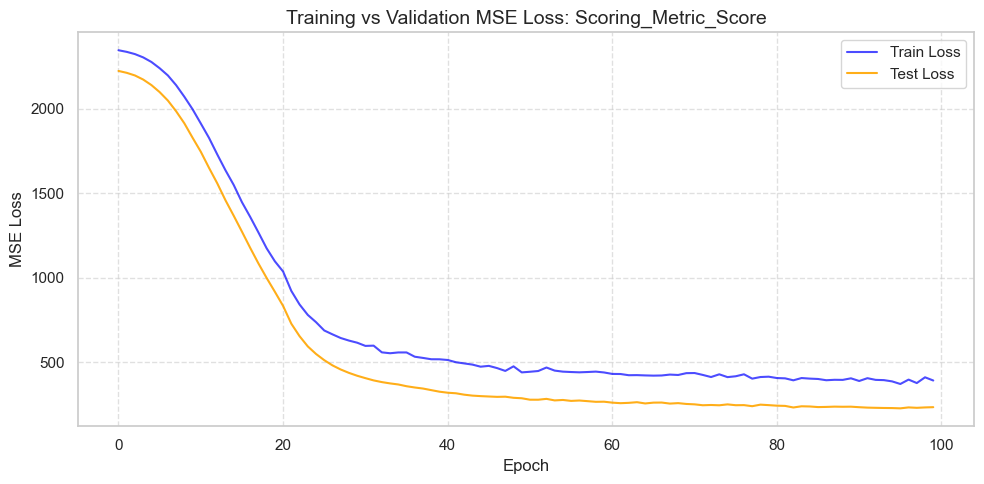

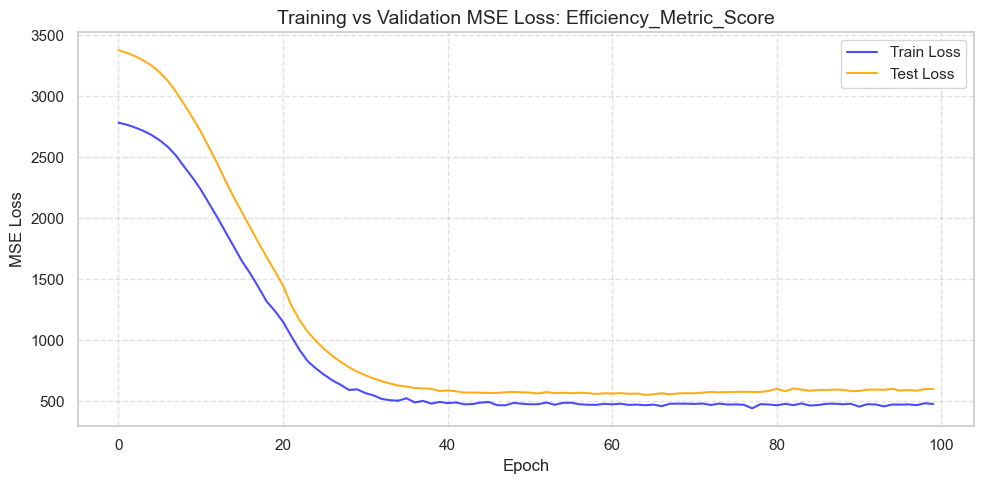

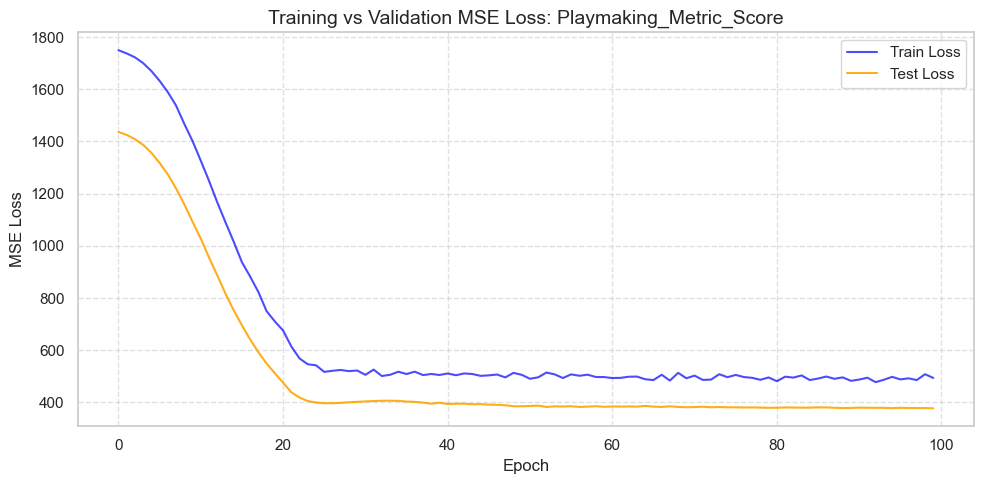

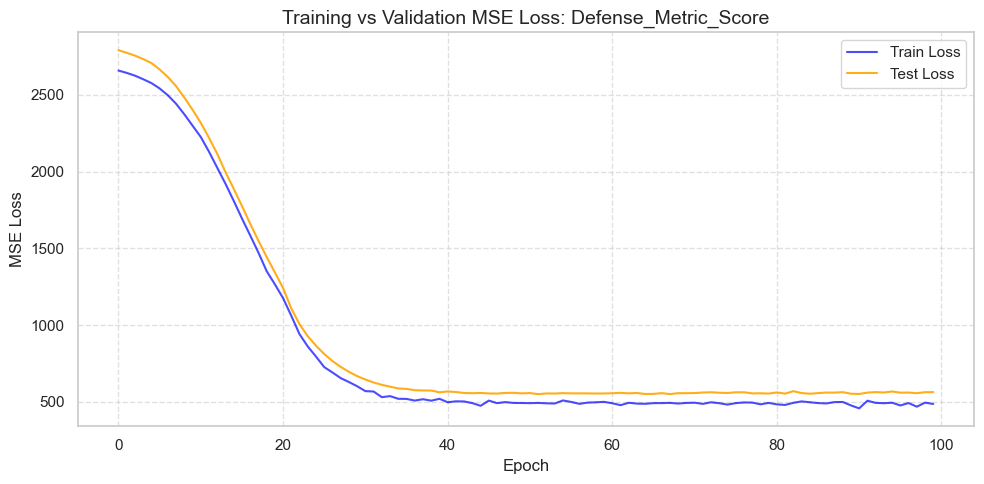

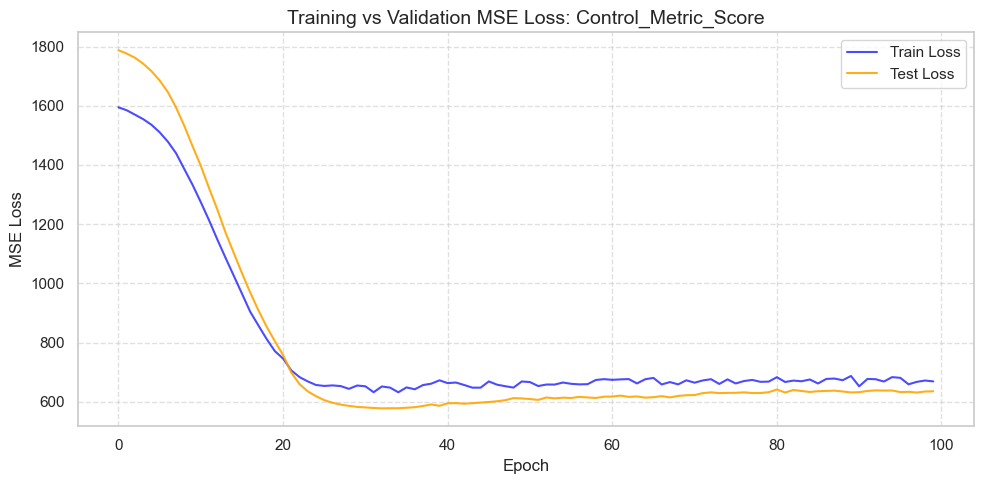

In [20]:
# Plotting Training vs Test Loss Curves
target_names = TARGET_COLS

for i in range(5):
    # Create a brand new figure for each target
    plt.figure(figsize=(10, 5)) 
    
    plt.plot(train_loss_history[i], label='Train Loss', color='blue', alpha=0.7)
    plt.plot(val_loss_history[i], label='Test Loss', color='orange', alpha=0.9)
    
    # Set titles and labels for this specific graph
    plt.title(f"Training vs Validation MSE Loss: {target_names[i]}", fontsize=14)
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("MSE Loss", fontsize=12)
    
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    
    # Display the current graph before moving to the next target
    plt.show()

In [21]:
def draw_radar_chart(player_name, actual_scores, predicted_scores, target_names):
    # Number of variables
    num_vars = len(target_names)

    # Compute angle for each axis
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

    # The plot is circular, so we need to "complete the loop"
    actual_scores = np.concatenate((actual_scores, [actual_scores[0]]))
    predicted_scores = np.concatenate((predicted_scores, [predicted_scores[0]]))
    angles += angles[:1]
    
    # Initialize the spider plot
    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    
    # Draw one axe per variable and add labels
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(target_names, fontsize=10, fontweight='bold')
    
    # Set y-axis bounds (Assuming scores are 0-100)
    ax.set_ylim(0, 100)
    
    # Plot Actual
    ax.plot(angles, actual_scores, color='blue', linewidth=2, label='Actual Score')
    ax.fill(angles, actual_scores, color='blue', alpha=0.1)
    
    # Plot Predicted
    ax.plot(angles, predicted_scores, color='red', linewidth=2, linestyle='dashed', label='Predicted Score')
    ax.fill(angles, predicted_scores, color='red', alpha=0.1)
    
    plt.title(f"Performance Forecast: {player_name}", size=14, y=1.1)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.show()

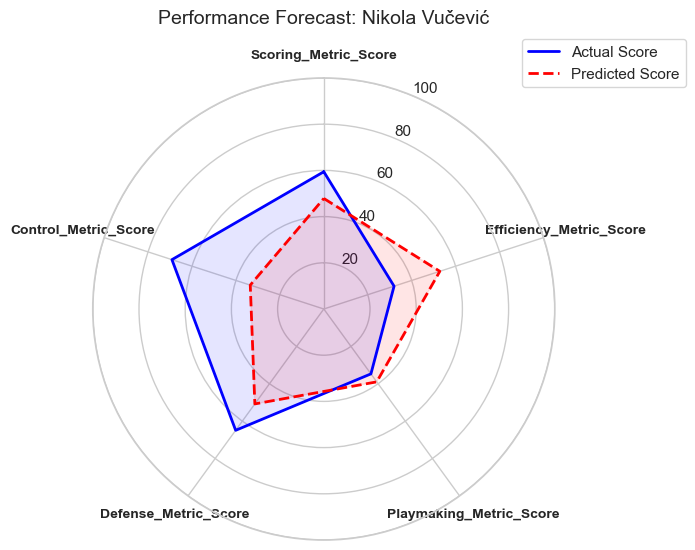

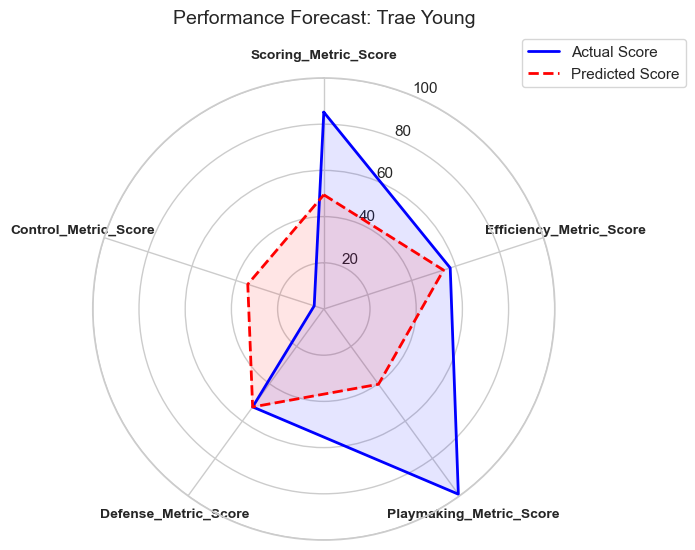

In [22]:
# Radar Chart Evaluation
HARDCODE_TEST_ID = [1629027, 202696]

model = MultiLevelForecastingNetwork(
    shot_dim=len(shot_features),
    game_dim=len(game_features),
    season_dim=len(season_features),
    shot_hidden=32, 
    game_hidden=32, 
    rnn_hidden=32,
    output_dim=len(TARGET_COLS)
).to(device)

model_path = PROJECT_ROOT / "src" / "Player Performance Analysis" / 'best_radar_score_model.pth'
model.load_state_dict(torch.load(model_path))
model.eval()

all_results = []

with torch.no_grad():
    for idx, row in enumerate(test_dataset.samples):
        # Fetch the specific pre-processed tensors for this player from the dataset
        shots, games, seasons, target = test_dataset[idx]
        
        # Add batch dimension (unsqueeze) and send to device
        shots = shots.unsqueeze(0).to(device)
        games = games.unsqueeze(0).to(device)
        seasons = seasons.unsqueeze(0).to(device)
        
        # Make prediction
        prediction = model(shots, games, seasons)
        
        # Extract values to numpy arrays for plotting
        actual_vals = target.numpy()
        predicted_vals = prediction.squeeze(0).cpu().numpy()

        all_results.append({
            'PLAYER_ID': row['PLAYER_ID'],
            'PLAYER_NAME': row['PLAYER_NAME'],
            'INPUT_SEASON': row['INPUT_SEASON'],
            'FORECAST_SEASON': row['FORECAST_SEASON'],
            'Scoring_Score_Actual': actual_vals[0],
            'Efficiency_Score_Actual': actual_vals[1],
            'Playmaking_Score_Actual': actual_vals[2],
            'Defense_Score_Actual': actual_vals[3],
            'Control_Score_Actual': actual_vals[4],
            'Scoring_Score_Predicted': predicted_vals[0],
            'Efficiency_Score_Predicted': predicted_vals[1],
            'Playmaking_Score_Predicted': predicted_vals[2],
            'Defense_Score_Predicted': predicted_vals[3],
            'Control_Score_Predicted': predicted_vals[4]
        })

        # Draw
        if row['PLAYER_ID'] in HARDCODE_TEST_ID:
            draw_radar_chart(
                player_name=row['PLAYER_NAME'], 
                actual_scores=actual_vals, 
                predicted_scores=predicted_vals, 
                target_names=TARGET_COLS
            )


results_df = pd.DataFrame(all_results)
# For consistency change Nikola Vučević to Nikola Vucevic
results_df.loc[results_df['PLAYER_ID'] == 202696, 'PLAYER_NAME'] = 'Nikola Vucevic'
results_df.to_csv(PROJECT_ROOT / "data" / "player_performance_testset_forecast_result.csv", index=False)

In [23]:
# Potentially use these as features??
# cluster_modeling_predictors_k5
# shot_embedding_player